In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df = pd.read_csv("/content/spam.csv", encoding='latin1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [10]:
df = df.rename(columns={
    "v1":"label",
    "v2":"message"
})

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       5572 non-null   object
 1   message     5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
df.isnull().sum()

,0
label,0
message,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [13]:
df.drop_duplicates(inplace=True)

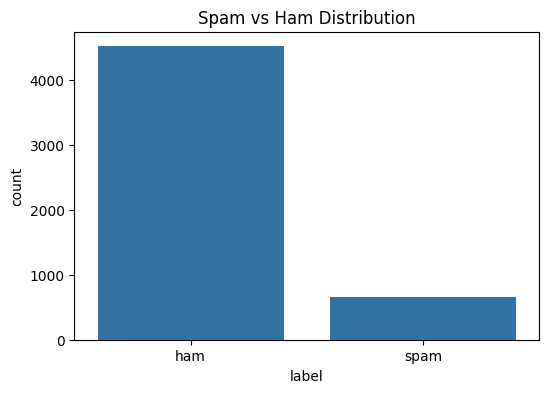

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['label']
)

plt.title("Spam vs Ham Distribution")
plt.show()

In [15]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [16]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        '[^a-zA-Z]',
        ' ',
        text
    )

    return text


df['message'] = df['message'].apply(clean_text)

In [17]:
X = df['message']

y = df['label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
tfidf = TfidfVectorizer(
    stop_words='english'
)


X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [19]:
model = MultinomialNB()


model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy_score(
    y_test,
    y_pred
)

0.9690522243713733

In [22]:
print(
classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.78      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



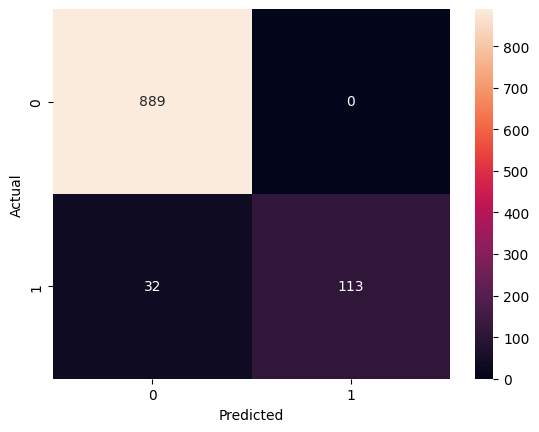

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
email = [
    "Ok lar... Joking with u "
]


email = tfidf.transform(email)

prediction = model.predict(email)

if prediction[0]==1:
    print("Spam Email")

else:
    print("Not Spam")

Not Spam
